**Installing dependencies**

In [1]:
GROQ_MODEL = "openai/gpt-oss-20b"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
COLLECTION_NAME = "telecom_hybrid"
# GitHub raw base URL for all data files
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/prabhu121995/sample-docs/refs/heads/main"
TICKETS_URL  = f"{GITHUB_RAW_BASE}/tickets.db"

### **SQL RAG**

So far, we've retrieved from **unstructured text** (PDFs, FAQ documents). But a lot of enterprise data lives in **relational databases** — support tickets, orders, usage records.

**SQL RAG** lets users ask natural-language questions against a SQL database:

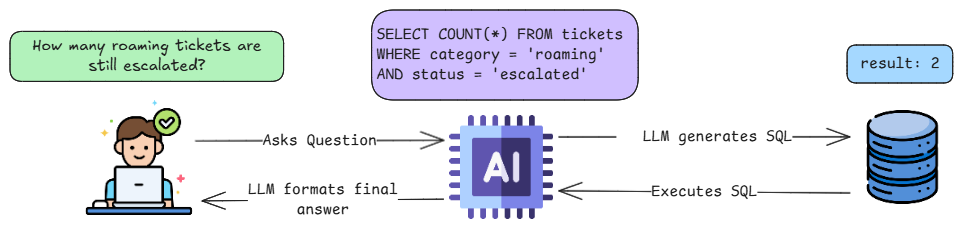

### **Explore the Database**

In [2]:
import requests
import tempfile
import os
from langchain_community.utilities import SQLDatabase

# SQLite needs a local file — download tickets.db from GitHub
response = requests.get(TICKETS_URL)
response.raise_for_status()

# Write to a temp file that persists for the notebook session
db_path = os.path.join(tempfile.gettempdir(), "tickets.db")
with open(db_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded tickets.db → {db_path}")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2492\2715563069.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


Downloaded tickets.db → C:\Users\ADMIN\AppData\Local\Temp\tickets.db


In [3]:
db = SQLDatabase.from_uri(f"sqlite:///{db_path}")

print("Tables:", db.get_usable_table_names())
print("\nSchema:")
print(db.get_table_info())

Tables: ['tickets']

Schema:

CREATE TABLE tickets (
	id INTEGER, 
	ticket_id TEXT NOT NULL, 
	category TEXT NOT NULL, 
	issue_type TEXT NOT NULL, 
	description TEXT NOT NULL, 
	resolution TEXT NOT NULL, 
	status TEXT DEFAULT 'resolved' NOT NULL, 
	PRIMARY KEY (id), 
	UNIQUE (ticket_id)
)

/*
3 rows from tickets table:
id	ticket_id	category	issue_type	description	resolution	status
1	TK-001	connectivity	No internet access	Customer reports complete loss of mobile internet after switching from 3G to 4G mode.	Guided customer to toggle airplane mode and reset APN settings. Internet restored after APN was rese	resolved
2	TK-002	connectivity	Intermittent signal drops	Customer in a suburban area experiences signal dropping to zero several times per day, affecting bot	Network team identified a faulty sector antenna on the nearest tower. Temporary fix applied remotely	resolved
3	TK-003	data	Data balance not updating	Customer purchased a 5 GB add-on pack but the balance still shows the old figure

Let's see a few sample rows

In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(db_path)
df_tickets = pd.read_sql("SELECT * FROM tickets LIMIT 5", conn)
conn.close()

print(f"Columns: {list(df_tickets.columns)}")
print(f"\nSample rows:")
df_tickets[["ticket_id", "category", "issue_type", "status"]].head(5)

Columns: ['id', 'ticket_id', 'category', 'issue_type', 'description', 'resolution', 'status']

Sample rows:


,ticket_id,category,issue_type,status
0,TK-001,connectivity,No internet access,resolved
1,TK-002,connectivity,Intermittent signal drops,resolved
2,TK-003,data,Data balance not updating,resolved
3,TK-004,roaming,Unexpected roaming charges,resolved
4,TK-005,sim,SIM card not recognised after phone update,resolved


# **Quick stats**

In [5]:
conn = sqlite3.connect(db_path)
stats = pd.read_sql("""
    SELECT category, status, COUNT(*) as count
    FROM tickets
    GROUP BY category, status
    ORDER BY category
""", conn)
conn.close()
print(stats)

       category     status  count
0       account  escalated      1
1       account   resolved      1
2       billing   resolved      3
3  connectivity   resolved      4
4          data   resolved      3
5        device   resolved      1
6       roaming   resolved      2
7           sim   resolved      3
8         voice   resolved      2


### **Build the SQL QA Chain**

In [6]:
import re

def clean_sql(raw: str) -> str:
    """Strip markdown fences and any preamble, leaving only the SQL statement."""
    raw = re.sub(r"```(?:sql)?", "", raw).strip("`").strip()
    # If the LLM prefixed with 'SQLQuery:' or 'Question: ...\nSQLQuery:', keep only what's after
    if "SQLQuery:" in raw:
        raw = raw.split("SQLQuery:")[-1].strip()
    return raw

In [7]:
from langchain_classic.chains import create_sql_query_chain
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

sql_query_chain = create_sql_query_chain(llm, db)

In [8]:
SYSTEM_PROMPT = """You are a TelecomCo support analytics assistant.
Given a user question and the SQL query result from our tickets database,
provide a clear, concise natural language answer.
Be specific with numbers and facts from the data."""

In [9]:
def sql_rag_chain(question: str) -> str:
    # Step 1: Generate SQL from the natural language question
    raw_sql = sql_query_chain.invoke({"question": question})
    sql = clean_sql(raw_sql)
    print(f"[debug] cleaned SQL → {sql}")

    # Step 2: Execute the SQL against the database
    result = db.run(sql)

    # Step 3: Ask the LLM to turn the raw result into a natural language answer
    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", "Question: {question}\nSQL Result: {result}\n\nAnswer:"),
    ])
    response = answer_prompt | llm
    return response.invoke({"question": question, "result": result}).content

print("✅ sql_rag_chain function ready")

✅ sql_rag_chain function ready


In [10]:
def ask_sql(question: str):
    print(f"Question: {question}")
    answer = sql_rag_chain(question)
    print(f"Answer:   {answer}")
    print("-" * 60)

ask_sql("How many tickets are in each category?")

Question: How many tickets are in each category?
[debug] cleaned SQL → SELECT "category", COUNT(*) AS ticket_count
FROM tickets
GROUP BY "category"
LIMIT 5;
Answer:   There are a total of 13 tickets distributed across five categories:

- **Account** – 2 tickets  
- **Billing** – 3 tickets  
- **Connectivity** – 4 tickets  
- **Data** – 3 tickets  
- **Device** – 1 ticket
------------------------------------------------------------


In [11]:
ask_sql("What is the most common issue type in the connectivity category?")

Question: What is the most common issue type in the connectivity category?
[debug] cleaned SQL → SELECT "issue_type", COUNT(*) AS cnt
FROM tickets
WHERE "category" = 'connectivity'
GROUP BY "issue_type"
ORDER BY cnt DESC, "issue_type" ASC
LIMIT 1;
Answer:   The most common issue type in the connectivity category is **“Extremely slow 4G speeds (below 1 Mbps)”**, with **1 ticket** reported.
------------------------------------------------------------


In [12]:
ask_sql("How many tickets have been resolved vs escalated?")

Question: How many tickets have been resolved vs escalated?
[debug] cleaned SQL → 
Answer:   I’m ready to help, but I’ll need the actual numbers from the SQL result to give you an accurate answer. Could you share the query output (or the counts of resolved and escalated tickets)?
------------------------------------------------------------
